<a href="https://colab.research.google.com/github/carn51/Assignment-1/blob/main/assignment3_4_4_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5PAM2034-0105-2025 - Assignment 3 - Data Analysis and Exploration

NAME:
STUDENT ID:

In this assignment, you are tasked with exploring a dataset using machine learning algorithms. You will train and evaluate a Random Forest Regressor to predict prices of regional flights in India.

You will need to write a short (1-2 page) report to accompany your code, explaining your results and analysis of the dataset.

In [138]:
#Module Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import ensemble

#Add any additional imports here


# Data Processing

The dataset used in this assignment can be found on [Kaggle](https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction). You will be using the data for the Economy class flights only, and will need to clean up the dataset.

Begin by loading in the economy.csv file, which is linked in the Canvas assignment, using pandas. You will need to derive new features from the data to create something you can train models with. The features in your training dataset should be:

FEATURES
1) Airline: The name of the airline company. Categorical.
2) Source City: City from which the flight takes off. Categorical.
3) Departure Time: Split the departure times into 3 categories based on the time, [Morning, Daytime, Night]. Categorical.
4) Stops: The number of stops on the flight path. Categorical.
5) Arrival Time: Split the departure times into 3 categories based on the time, [Morning, Daytime, Night]. Categorical.
6) Destination City: City where the flight will land. Categorical.
7) Duration: The number of hours the flight takes as a continuous real number. Continuous.
8) Lead Time: The number of days between the flight date and the booking date. Discrete.
11) Price: The cost of the flight. Continuous.

Drop any unused features from the dataset, such as the flight code, separate out the target variable and split into a training and testing set.

In [139]:
data = pd.read_csv('/content/economy.csv')
df = pd.DataFrame(data)
df.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


Initial transformations

In [140]:
#turn airline, to and from columns categorical
df['airline'] = df['airline'].astype('category')

#rename to and from to src and destination
df['Source_City'] = df['from'].astype('category')
df['Destination_City'] = df['to'].astype('category')

#further columns require string manipulation and other operations
#reformat then cut both time columns
df['dep_time'] = df['dep_time'].str.replace(':', '').astype(int)
df['arr_time'] = df['arr_time'].str.replace(':', '').astype(int)

bins = [0000, 1200, 2000, 2359]
labels = ['Morning', 'Daytime', 'Night']

df['dep_time'] = pd.cut(df['dep_time'], bins=bins, labels = labels)
df['arr_time'] = pd.cut(df['arr_time'], bins=bins, labels = labels)

#time taken conversion to duration
#first remove extra characters, using a list

replacements = [('h', ''), ('m', ''), (' ', '')]

for old_, new_ in replacements:
    df['time_taken'] = df['time_taken'].str.replace(old_, new_)

#index the minutes and convert them to a decimal to add back on
for vals in df['time_taken'][-2:].astype(float):
  df['minutes_decimal'] = vals / 60 * 100
#take the first 2 digits for hours
df['hours'] = df['time_taken'].str[:2]
df['duration'] = (df['hours'] + df['minutes_decimal'].astype(str))
#take away the decimal point
df['duration'] = df['duration'].str.replace('.', '')

#back to  a float
df['duration'] = df['duration'].str[:4]
df['duration'] = df['duration'].astype(float) / 100
df['duration'].head()

,duration
0,2.4
1,2.4
2,2.4
3,2.4
4,2.4


Stops column

In [141]:
for stopval in df['stop']:
  stopval = np.where(stopval == 'non-stop', 0, 1)

df['stop'] = stopval
df['stop'].head()

,stop
0,1
1,1
2,1
3,1
4,1


Lead times: since Feb 11, 2022

In [142]:
from datetime import datetime

dates_list = []
#assign current format as a string
format = '%d-%m-%Y'

#make our dates adhere to the accepted format
#by iterating over rows with strptime
for datestrings in df['date']:
  dates_list.append(datetime.strptime(datestrings, format))

date0 = datetime(2022, 2, 11, 0, 0)

days_between  = []

for dates in dates_list:
  days_between.append(np.abs(date0 - dates))

#turn into a column
df['lead_time'] = pd.Series(days_between).astype(int)

Make price continuous, observe distribution

<Axes: title={'center': 'Distribution of Prices'}, xlabel='Prices'>

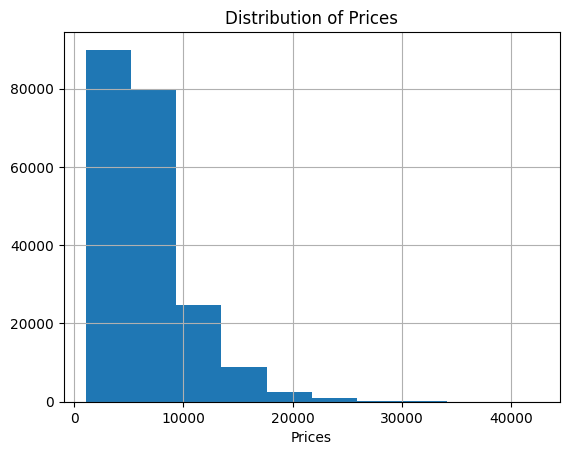

In [143]:
df['price'] = df['price'].str.replace(',', '')
df['price'] = df['price'].astype(float)

plt.title("Distribution of Prices")
plt.xlabel("Prices")
df['price'].hist()

In [144]:
#list all categorical columns
catcols = df.select_dtypes(include=['category']).columns.tolist()
print(catcols)

#create the encoder
from sklearn.preprocessing import OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)
onehot_done = encoder.fit_transform(df[catcols])

#make note of column names
cols = encoder.get_feature_names_out(catcols)

#create a df with these columns
onehot_df = pd.DataFrame(onehot_done, columns = cols)
#add it back to df
df = pd.concat([df, onehot_df], axis=1)
df.head()

['airline', 'dep_time', 'arr_time', 'Source_City', 'Destination_City']


,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,...,Source_City_Delhi,Source_City_Hyderabad,Source_City_Kolkata,Source_City_Mumbai,Destination_City_Bangalore,Destination_City_Chennai,Destination_City_Delhi,Destination_City_Hyderabad,Destination_City_Kolkata,Destination_City_Mumbai
0,11-02-2022,SpiceJet,SG,8709,Daytime,Delhi,0210,1,Night,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,11-02-2022,SpiceJet,SG,8157,Morning,Delhi,0220,1,Morning,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
2,11-02-2022,AirAsia,I5,764,Morning,Delhi,0210,1,Morning,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,11-02-2022,Vistara,UK,995,Morning,Delhi,0215,1,Daytime,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
4,11-02-2022,Vistara,UK,963,Morning,Delhi,0220,1,Morning,Mumbai,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


Drop unnecessary columns

In [145]:
df = df.drop(columns = ['airline', 'dep_time', 'arr_time', 'Source_City', 'Destination_City', 'date', 'ch_code', 'num_code', 'from', 'time_taken', 'to', 'minutes_decimal', 'hours'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206774 entries, 0 to 206773
Data columns (total 30 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   stop                        206774 non-null  int64  
 1   price                       206774 non-null  float64
 2   duration                    206774 non-null  float64
 3   lead_time                   206774 non-null  int64  
 4   airline_Air India           206774 non-null  float64
 5   airline_AirAsia             206774 non-null  float64
 6   airline_GO FIRST            206774 non-null  float64
 7   airline_Indigo              206774 non-null  float64
 8   airline_SpiceJet            206774 non-null  float64
 9   airline_StarAir             206774 non-null  float64
 10  airline_Trujet              206774 non-null  float64
 11  airline_Vistara             206774 non-null  float64
 12  dep_time_Daytime            206774 non-null  float64
 13  dep_time_Morni

# Model Training

Implement and train a random forest regressor, using sklearn. Explore a range of hyperparamter settings for the model to find the best fitting result.

In [153]:
from sklearn.model_selection import train_test_split

#define features then split
y = df['price']
X = df.drop(columns='price')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=23)

from sklearn.ensemble import RandomForestRegressor

rf_reg = RandomForestRegressor(oob_score= True,
                               n_estimators = 500)

rf_reg.fit(X_train, y_train)
y_preds = rf_reg.predict(X_test)

print(y_preds)

[ 4160.2535619   7439.96736429 10020.87229048 ...  5621.2452381
  5876.72        6539.494     ]


In [154]:
from sklearn import tree

tree.plot_tree(rf_reg.estimators_[0])

[Text(0.35600382794601215, 0.9875, 'x[2] <= 1252799950094336.0\nsquared_error = 14058425.905\nsamples = 104418\nvalue = 6580.999'),
 Text(0.08320088791153672, 0.9625, 'x[1] <= 3.9\nsquared_error = 18218993.419\nsamples = 27612\nvalue = 10572.747'),
 Text(0.21960235792877444, 0.9750000000000001, 'True  '),
 Text(0.013576378976617762, 0.9375, 'x[1] <= 1.9\nsquared_error = 4510219.137\nsamples = 3935\nvalue = 6462.743'),
 Text(0.004343472927360377, 0.9125, 'x[2] <= 216000003833856.0\nsquared_error = 2906897.402\nsamples = 1080\nvalue = 5183.436'),
 Text(0.0014183611399922614, 0.8875, 'x[26] <= 0.5\nsquared_error = 9672374.091\nsamples = 141\nvalue = 7251.137'),
 Text(0.000947012228831335, 0.8625, 'x[15] <= 0.5\nsquared_error = 9939679.535\nsamples = 98\nvalue = 7888.953'),
 Text(0.0004931905941151798, 0.8375, 'x[6] <= 0.5\nsquared_error = 9474161.077\nsamples = 57\nvalue = 8754.633'),
 Text(0.00025131417917733604, 0.8125, 'x[10] <= 0.5\nsquared_error = 5797725.34\nsamples = 23\nvalue = 72

Error in callback <function _draw_all_if_interactive at 0x7d7f2fb24e00> (for post_execute):


KeyboardInterrupt: 

Error in callback <function flush_figures at 0x7d7f2fcfe340> (for post_execute):


KeyboardInterrupt: 

# Analysis

Evaluate the results of your model, consider how the pricing of flights relates to other features in the dataset, such as the carrier or departure time, and use your trained model to support any conclusions. Create any relevant plots to include in your report.

In [152]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_preds)
r2 = r2_score(y_test, y_preds)
oob = rf_reg.oob_score_

print(mse)
print(r2)
print(oob)

def r2_adj(R2, n, p):
  return 1 - (((1 - R2) * (n - 1))/(n-p-1))

print("ADJUSTED R2")
#8 predictors, 206774 rows
print(3192563.183, 206774, 8)

3192563.183698917
0.7717360394625286
0.7752421174476871
ADJUSTED R2
3192563.183 206774 8


Predicted vs Actual

In [ ]:
plt.scatter(y_test, y_preds)
plt.show()